In [29]:
import pandas as pd
import re

# Put your actual file name here
file_path = "raw_data.txt"

cleaned_rows = []

with open(file_path, "r") as f:
    for line in f:
        # Remove timestamp part before ->
        if "->" in line:
            line = line.split("->")[1].strip()
        else:
            line = line.strip()
        
        # Skip empty lines
        if line:
            cleaned_rows.append(line)

# Convert cleaned text into DataFrame
from io import StringIO

cleaned_text = "\n".join(cleaned_rows)

data = pd.read_csv(
    StringIO(cleaned_text),
    header=None,
    names=["time_ms", "raw_adc", "moisture_percent", "label"]
)

# Convert to numeric (important)
data = data.apply(pd.to_numeric, errors='coerce')
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

# Save processed CSV
data.to_csv("processed_soil_data.csv", index=False)

print("Preprocessing complete.")
print(data.head())
print("\nTotal samples:", len(data))


Preprocessing complete.
   time_ms  raw_adc  moisture_percent  label
0   500000     1482              79.8      0
1   501000     1501              78.4      0
2   502000     1468              80.7      0
3   503000     1520              77.0      0
4   504000     1445              82.5      0

Total samples: 100


In [30]:
import pandas as pd

# Load processed CSV
data = pd.read_csv("processed_soil_data.csv")

print("Dataset Preview:")
print(data.head())

print("\nClass Distribution:")
print(data["label"].value_counts())

Dataset Preview:
   time_ms  raw_adc  moisture_percent  label
0   500000     1482              79.8      0
1   501000     1501              78.4      0
2   502000     1468              80.7      0
3   503000     1520              77.0      0
4   504000     1445              82.5      0

Class Distribution:
label
0    60
1    40
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

# Features
X = data[["raw_adc", "moisture_percent"]]

# Target
y = data["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("=== KNN Results ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

=== KNN Results ===
Accuracy: 1.0
Confusion Matrix:
 [[13  0]
 [ 0  7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

=== Decision Tree Results ===
Accuracy: 1.0
Confusion Matrix:
 [[13  0]
 [ 0  7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

=== Logistic Regression Results ===
Accuracy: 1.0
Confusion Matrix:
 [[13  0]
 [ 0  7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [36]:
print("Model Comparison:")
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Model Comparison:
KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 1.0


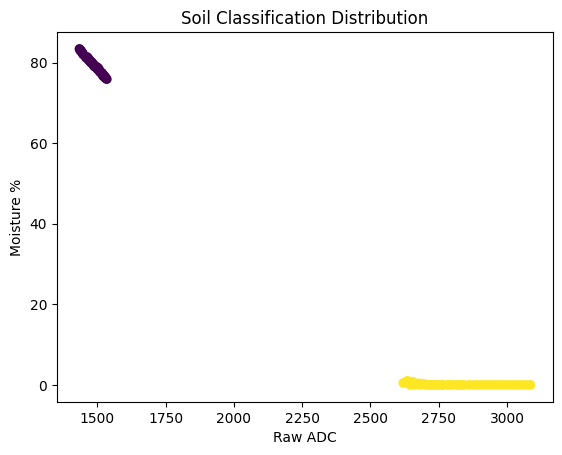

In [38]:
import matplotlib.pyplot as plt

plt.scatter(data["raw_adc"], data["moisture_percent"], c=data["label"])
plt.xlabel("Raw ADC")
plt.ylabel("Moisture %")
plt.title("Soil Classification Distribution")
plt.show()